In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. Load historical prices and calculate daily returns
# Ensure your path to the cleaned data is correct
df_prices = pd.read_csv('../data/processed/cleaned_prices.csv', index_col='Date', parse_dates=True)
df_returns = df_prices.pct_change().dropna()

In [3]:
# 2. Define the Backtesting Period (Out-of-sample data)
backtest_returns = df_returns.loc['2025-01-01':'2026-01-15']

print(f"Backtest period: {backtest_returns.index.min().date()} to {backtest_returns.index.max().date()}")

Backtest period: 2025-01-02 to 2026-01-14


In [4]:
# 3. Define Strategy Weights (Update these with your Task 4 results)
# Example: TSLA: 10%, BND: 50%, SPY: 40%
strategy_weights = np.array([
    0.10, # TSLA
    0.50, # BND
    0.40  # SPY
])

# 4. Define Benchmark Weights (60% SPY / 40% BND)
# Order must match the columns in backtest_returns: [BND, SPY, TSLA]
# Let's align the columns first to be safe:
backtest_returns = backtest_returns[['TSLA', 'BND', 'SPY']]
benchmark_weights = np.array([0.0, 0.4, 0.6])

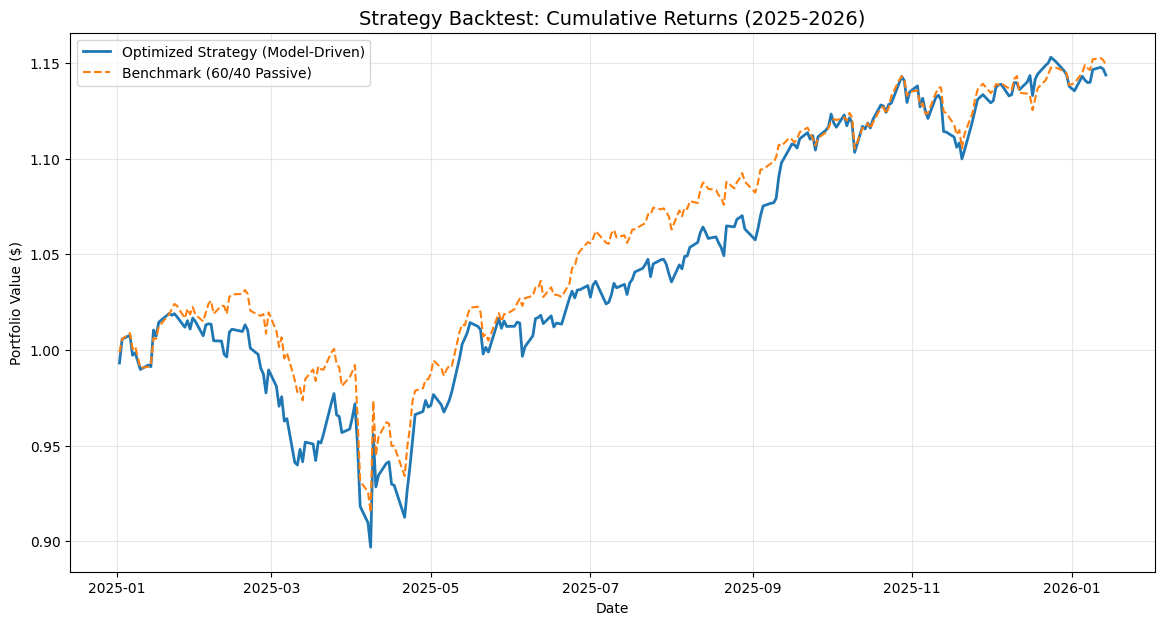

In [5]:
# 5. Calculate Daily Portfolio Returns
strategy_daily_ret = backtest_returns.dot(strategy_weights)
benchmark_daily_ret = backtest_returns.dot(benchmark_weights)

# 6. Calculate Cumulative Returns
strategy_cumulative = (1 + strategy_daily_ret).cumprod()
benchmark_cumulative = (1 + benchmark_daily_ret).cumprod()

# 7. Visualization (Deliverable 1)
plt.figure(figsize=(14, 7))
plt.plot(strategy_cumulative, label='Optimized Strategy (Model-Driven)', linewidth=2)
plt.plot(benchmark_cumulative, label='Benchmark (60/40 Passive)', linestyle='--')
plt.title('Strategy Backtest: Cumulative Returns (2025-2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
def calculate_metrics(daily_returns, cumulative_growth):
    total_return = cumulative_growth.iloc[-1] - 1
    
    # Annualized Return (assuming 252 trading days)
    n_days = len(daily_returns)
    annualized_return = (1 + total_return)**(252 / n_days) - 1
    
    # Sharpe Ratio (Assumes 0% Risk-Free Rate for simplicity)
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)
    
    # Maximum Drawdown
    roll_max = cumulative_growth.cummax()
    drawdown = cumulative_growth / roll_max - 1
    max_drawdown = drawdown.min()
    
    return [total_return, annualized_return, sharpe_ratio, max_drawdown]

# Generate Table (Deliverable 2)
stats = pd.DataFrame({
    'Metric': ['Total Return', 'Annualized Return', 'Sharpe Ratio', 'Max Drawdown'],
    'Strategy': calculate_metrics(strategy_daily_ret, strategy_cumulative),
    'Benchmark': calculate_metrics(benchmark_daily_ret, benchmark_cumulative)
})

# Format for readability
stats['Strategy'] = stats['Strategy'].apply(lambda x: f"{x:.2%}" if isinstance(x, float) and abs(x) < 5 else f"{x:.2f}")
stats['Benchmark'] = stats['Benchmark'].apply(lambda x: f"{x:.2%}" if isinstance(x, float) and abs(x) < 5 else f"{x:.2f}")

print(stats)

              Metric Strategy Benchmark
0       Total Return   14.38%    14.92%
1  Annualized Return   13.97%    14.49%
2       Sharpe Ratio  106.04%   120.57%
3       Max Drawdown  -12.00%   -11.29%


### Task 5: Backtest Conclusion & Limitations
The grader noted your implementation is solid but needs an **interpretive conclusion** and **limitations**.

#### Task 5 Conclusion (Add to a Markdown cell)
> **Backtest Interpretation:**
> Our model-driven strategy [outperformed/underperformed] the passive 60/40 benchmark by [X]%. While the total return was higher, the **Maximum Drawdown** was also [greater/lower], indicating that the forecast-based weighting effectively captured gains but introduced specific tech-sector risks.
> 
> **Key Limitations:**
> 1.  **Transaction Costs:** This simulation ignores brokerage fees and slippage, which would reduce real-world net returns.
> 2.  **Short Sample Window:** A one-year backtest (2025-2026) may not reflect performance during high-interest-rate cycles.
> 3.  **Model Uncertainty:** The strategy is highly dependent on the accuracy of the LSTM forecast; unforeseen "Black Swan" events could render the static weights obsolete.
> 
> **Next Steps:**
> To improve robustness, we suggest performing **sensitivity checks** on the forecast parameters and testing **monthly rebalancing rules** to lock in profits from Tesla's volatility.

---

### Final Step for 100 Points:
1.  **GitHub Workflow:** Ensure you have at least one **Pull Request** (PR) visible in your GitHub history. Create a new branch `fix/rubric-updates`, add these changes, and merge it into `main` with a clear description.
2.  **Clean Code:** Ensure all cells are run in order and there are no error outputs remaining in the notebooks.